<a href="https://colab.research.google.com/github/BalamuruganR2004/Data-Science-Project/blob/main/MLR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Upload your dataset
from google.colab import files

print("Please upload your ToyotaCorolla_-_MLR.csv file:")
uploaded = files.upload()

# Get the filename
filename = list(uploaded.keys())[0]
print(f"\n✅ File '{filename}' uploaded successfully!")

Please upload your ToyotaCorolla_-_MLR.csv file:


Saving ToyotaCorolla - MLR.csv to ToyotaCorolla - MLR (2).csv

✅ File 'ToyotaCorolla - MLR (2).csv' uploaded successfully!


In [ ]:
# ============================================
# IMPORT ALL REQUIRED LIBRARIES
# ============================================

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical tests
from scipy import stats

# Machine Learning - sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [ ]:
df = pd.read_csv(filename)
print("Dataset Shape:", df.shape[0], "rows x", df.shape[1], "columns")

Dataset Shape: 1436 rows x 11 columns


In [ ]:
df.dtypes

,0
Price,int64
Age_08_04,int64
KM,int64
Fuel_Type,object
HP,int64
Automatic,int64
cc,int64
Doors,int64
Cylinders,int64
Gears,int64


In [ ]:
df.isnull().sum()

,0
Price,0
Age_08_04,0
KM,0
Fuel_Type,0
HP,0
Automatic,0
cc,0
Doors,0
Cylinders,0
Gears,0


In [ ]:
df.duplicated().sum()

np.int64(1)

In [ ]:
df.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


In [ ]:
print("Mean Price:", df['Price'].mean())
print("Median Price:", df['Price'].median())
print("Min Price:", df['Price'].min())
print("Max Price:", df['Price'].max())
print("Std Deviation:", df['Price'].std())

Mean Price: 10730.824512534818
Median Price: 9900.0
Min Price: 4350
Max Price: 32500
Std Deviation: 3626.9645849102394


In [ ]:
df['Fuel_Type'].value_counts()

,count
Fuel_Type,
Petrol,1264
Diesel,155
CNG,17


In [ ]:
df.corr(numeric_only=True)['Price'].sort_values(ascending=False)

,Price
Price,1.000000
Weight,0.581198
HP,0.314990
Doors,0.185326
cc,0.126389
Gears,0.063104
Automatic,0.033081
KM,-0.569960
Age_08_04,-0.876590
Cylinders,NaN


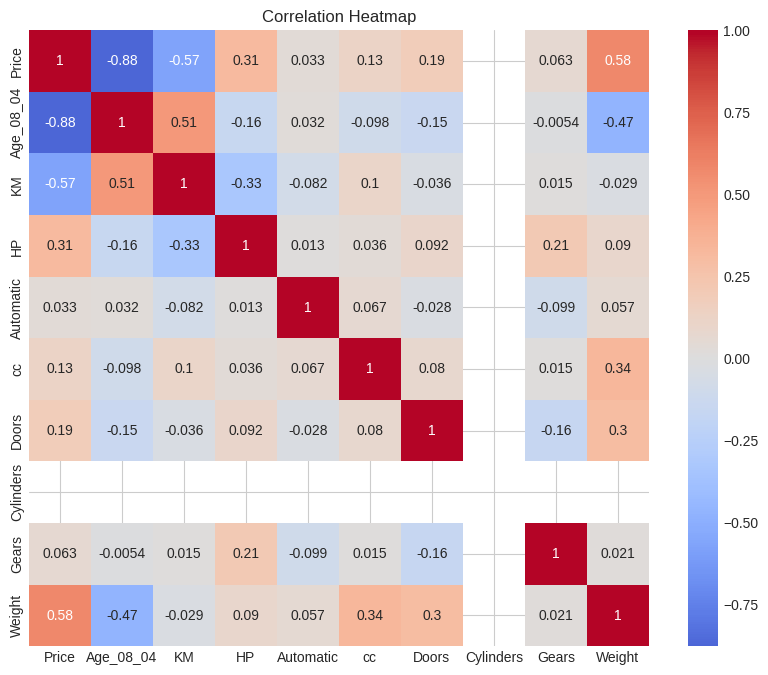

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

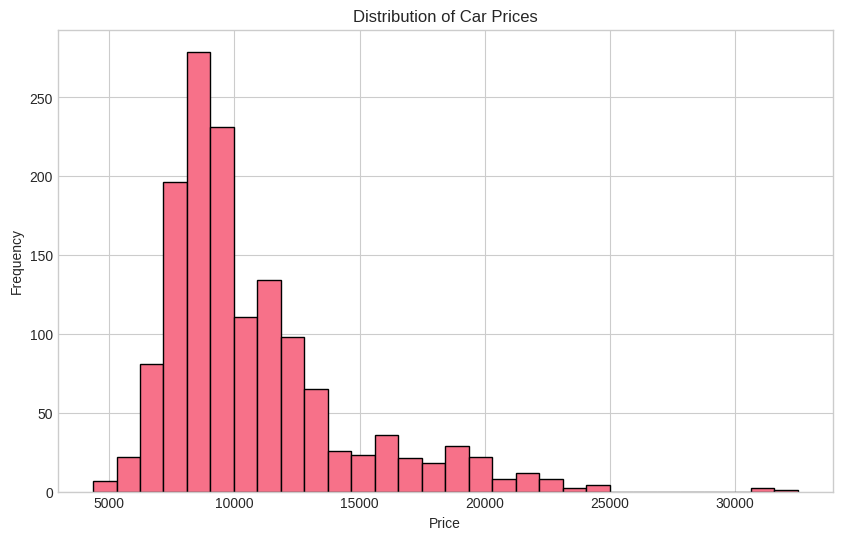

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(df['Price'], bins=30, edgecolor='black')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Distribution of Car Prices')
plt.show()

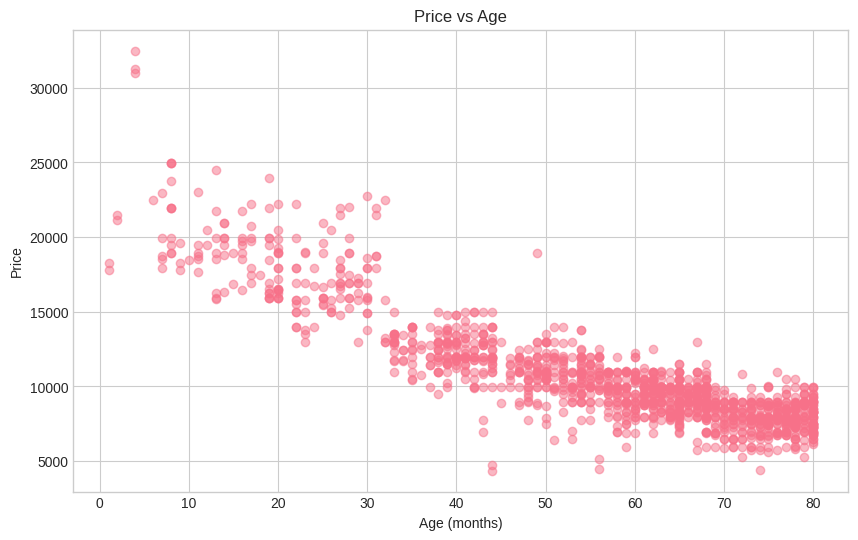

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Age_08_04'], df['Price'], alpha=0.5)
plt.xlabel('Age (months)')
plt.ylabel('Price')
plt.title('Price vs Age')
plt.show()

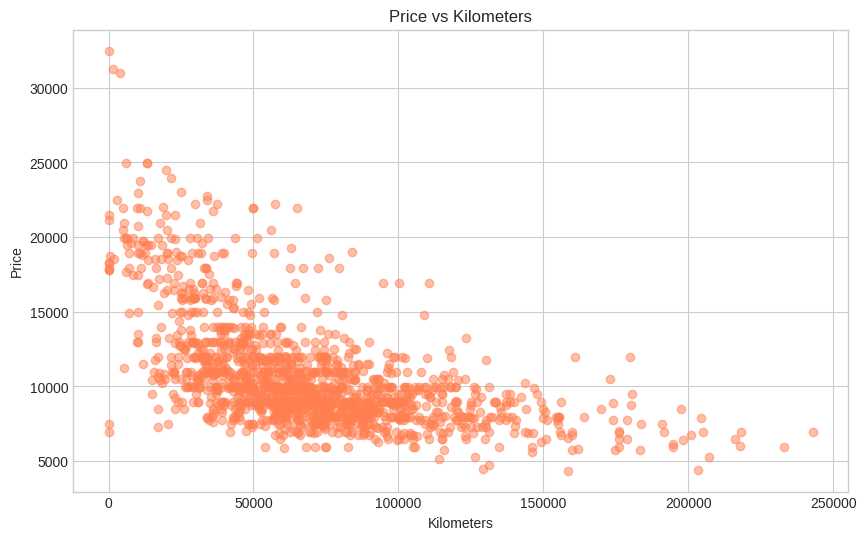

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(df['KM'], df['Price'], alpha=0.5, color='coral')
plt.xlabel('Kilometers')
plt.ylabel('Price')
plt.title('Price vs Kilometers')
plt.show()

<Figure size 1000x600 with 0 Axes>

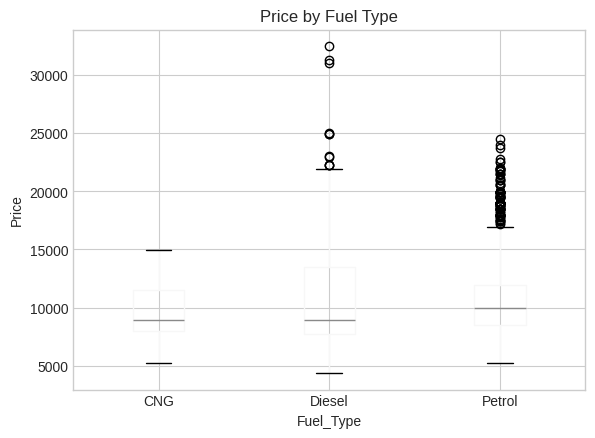

In [ ]:
plt.figure(figsize=(10, 6))
df.boxplot(column='Price', by='Fuel_Type')
plt.ylabel('Price')
plt.title('Price by Fuel Type')
plt.suptitle('')
plt.show()

In [ ]:
df_processed = df.copy()

In [ ]:
fuel_dummies = pd.get_dummies(df_processed['Fuel_Type'], prefix='Fuel', drop_first=True)
df_processed = pd.concat([df_processed, fuel_dummies], axis=1)
df_processed.drop('Fuel_Type', axis=1, inplace=True)

In [ ]:
df_processed.columns.tolist()

['Price',
 'Age_08_04',
 'KM',
 'HP',
 'Automatic',
 'cc',
 'Doors',
 'Cylinders',
 'Gears',
 'Weight',
 'Fuel_Diesel',
 'Fuel_Petrol']

In [ ]:
df_processed.head()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Diesel,Fuel_Petrol
0,13500,23,46986,90,0,2000,3,4,5,1165,True,False
1,13750,23,72937,90,0,2000,3,4,5,1165,True,False
2,13950,24,41711,90,0,2000,3,4,5,1165,True,False
3,14950,26,48000,90,0,2000,3,4,5,1165,True,False
4,13750,30,38500,90,0,2000,3,4,5,1170,True,False


In [ ]:
X = df_processed.drop('Price', axis=1)
y = df_processed['Price']

In [ ]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1436, 11)
y shape: (1436,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
print("Training set:", X_train.shape[0], "samples")
print("Testing set:", X_test.shape[0], "samples")

Training set: 1148 samples
Testing set: 288 samples


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
print("Before scaling - X_train mean:", X_train.mean().mean())
print("After scaling - X_train_scaled mean:", X_train_scaled.mean().round(2))

Before scaling - X_train mean: 6518.659645232815
After scaling - X_train_scaled mean: 0.0


In [ ]:
model1 = LinearRegression()
model1.fit(X_train, y_train)

LinearRegression()

In [ ]:
coef_df1 = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': model1.coef_})
coef_df1 = coef_df1.sort_values('Coefficient', key=abs, ascending=False)
print(coef_df1)
print("\nIntercept:", model1.intercept_)

        Feature   Coefficient
10  Fuel_Petrol  1.370809e+03
7         Gears  5.516007e+02
3     Automatic  1.488309e+02
0     Age_08_04 -1.208305e+02
9   Fuel_Diesel -6.854876e+01
5         Doors -6.031097e+01
8        Weight  2.588496e+01
2            HP  1.403948e+01
4            cc -3.037219e-02
1            KM -1.623141e-02
6     Cylinders -1.620037e-12

Intercept: -14255.385993565254


In [ ]:
y_train_pred1 = model1.predict(X_train)
y_test_pred1 = model1.predict(X_test)

In [ ]:
print("Model 1: Full Model")
print("Train R2:", r2_score(y_train, y_train_pred1))
print("Test R2:", r2_score(y_test, y_test_pred1))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred1)))
print("Test MAE:", mean_absolute_error(y_test, y_test_pred1))

Model 1: Full Model
Train R2: 0.8702643169608926
Test R2: 0.8348888040611082
Test RMSE: 1484.2654153296514
Test MAE: 990.8872739193926


In [ ]:
top_features = ['Age_08_04', 'KM', 'HP', 'Weight', 'cc']
model2 = LinearRegression()
model2.fit(X_train[top_features], y_train)
y_test_pred2 = model2.predict(X_test[top_features])

print("Model 2: Reduced Model (5 features)")
print("Test R2:", r2_score(y_test, y_test_pred2))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred2)))

Model 2: Reduced Model (5 features)
Test R2: 0.8504087218447197
Test RMSE: 1412.786196593583


In [ ]:
simple_features = ['Age_08_04', 'KM', 'HP']
model3 = LinearRegression()
model3.fit(X_train[simple_features], y_train)
y_test_pred3 = model3.predict(X_test[simple_features])

print("Model 3: Parsimonious Model (3 features)")
print("Test R2:", r2_score(y_test, y_test_pred3))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred3)))

Model 3: Parsimonious Model (3 features)
Test R2: 0.8103259513824549
Test RMSE: 1590.8427891636334


In [ ]:
print("Model 3 Coefficients:")
for feature, coef in zip(simple_features, model3.coef_):
    print(f"  {feature}: {coef:.4f}")
print(f"  Intercept: {model3.intercept_:.2f}")

Model 3 Coefficients:
  Age_08_04: -153.6962
  KM: -0.0113
  HP: 34.6720
  Intercept: 16601.75


In [ ]:
X_train_interact = X_train.copy()
X_test_interact = X_test.copy()
X_train_interact['Age_KM'] = X_train['Age_08_04'] * X_train['KM'] / 10000
X_test_interact['Age_KM'] = X_test['Age_08_04'] * X_test['KM'] / 10000

model4 = LinearRegression()
model4.fit(X_train_interact, y_train)
y_test_pred4 = model4.predict(X_test_interact)

print("Model 4: Interaction Model")
print("Test R2:", r2_score(y_test, y_test_pred4))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred4)))

Model 4: Interaction Model
Test R2: 0.8621657410005827
Test RMSE: 1356.1317831454746


In [ ]:
print("\nModel Comparison:")
print("="*50)
print(f"Model 1 (Full):        R2 = {r2_score(y_test, y_test_pred1):.4f}")
print(f"Model 2 (5 features):  R2 = {r2_score(y_test, y_test_pred2):.4f}")
print(f"Model 3 (3 features):  R2 = {r2_score(y_test, y_test_pred3):.4f}")
print(f"Model 4 (Interaction): R2 = {r2_score(y_test, y_test_pred4):.4f}")


Model Comparison:
Model 1 (Full):        R2 = 0.8349
Model 2 (5 features):  R2 = 0.8504
Model 3 (3 features):  R2 = 0.8103
Model 4 (Interaction): R2 = 0.8622


In [ ]:
alphas = [0.01, 0.1, 1, 10, 100, 1000]
print("Ridge Regression Results:")
print("="*40)

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)
    y_pred = ridge.predict(X_test_scaled)
    r2 = r2_score(y_test, y_pred)
    print(f"Alpha = {alpha:6} | R2 = {r2:.4f}")

Ridge Regression Results:
Alpha =   0.01 | R2 = 0.8349
Alpha =    0.1 | R2 = 0.8349
Alpha =      1 | R2 = 0.8350
Alpha =     10 | R2 = 0.8363
Alpha =    100 | R2 = 0.8417
Alpha =   1000 | R2 = 0.7594


In [ ]:
ridge_best = Ridge(alpha=100)
ridge_best.fit(X_train_scaled, y_train)
y_pred_ridge = ridge_best.predict(X_test_scaled)

print("Best Ridge Model (alpha=100):")
print("R2 Score:", r2_score(y_test, y_pred_ridge))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))

Best Ridge Model (alpha=100):
R2 Score: 0.8416775069598967
RMSE: 1453.4316612219995


In [ ]:
ridge_coef = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': ridge_best.coef_})
ridge_coef = ridge_coef.sort_values('Coefficient', key=abs, ascending=False)
print(ridge_coef)

        Feature  Coefficient
0     Age_08_04 -2070.198371
8        Weight  1153.251521
1            KM  -719.773798
2            HP   286.765510
10  Fuel_Petrol   236.631820
7         Gears   111.814708
3     Automatic    42.850483
9   Fuel_Diesel   -26.680445
5         Doors     1.605719
4            cc    -0.615800
6     Cylinders     0.000000


In [ ]:
print("\nLasso Regression Results:")
print("="*40)

for alpha in alphas:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train_scaled, y_train)
    y_pred = lasso.predict(X_test_scaled)
    r2 = r2_score(y_test, y_pred)
    non_zero = np.sum(lasso.coef_ != 0)
    print(f"Alpha = {alpha:6} | R2 = {r2:.4f} | Features used = {non_zero}")


Lasso Regression Results:
Alpha =   0.01 | R2 = 0.8349 | Features used = 10
Alpha =    0.1 | R2 = 0.8349 | Features used = 10
Alpha =      1 | R2 = 0.8351 | Features used = 10
Alpha =     10 | R2 = 0.8371 | Features used = 9
Alpha =    100 | R2 = 0.8470 | Features used = 6
Alpha =   1000 | R2 = 0.6787 | Features used = 2


In [ ]:
lasso_best = Lasso(alpha=100, max_iter=10000)
lasso_best.fit(X_train_scaled, y_train)
y_pred_lasso = lasso_best.predict(X_test_scaled)

print("Best Lasso Model (alpha=100):")
print("R2 Score:", r2_score(y_test, y_pred_lasso))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lasso)))

Best Lasso Model (alpha=100):
R2 Score: 0.8470223470225781
RMSE: 1428.6876920736831


In [ ]:
lasso_coef = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': lasso_best.coef_})
lasso_coef = lasso_coef.sort_values('Coefficient', key=abs, ascending=False)
print(lasso_coef)

print("\nFeatures selected by Lasso (non-zero):")
selected = lasso_coef[lasso_coef['Coefficient'] != 0]['Feature'].tolist()
print(selected)

        Feature  Coefficient
0     Age_08_04 -2243.152110
8        Weight  1008.878685
1            KM  -646.292165
2            HP   294.336761
10  Fuel_Petrol   150.230602
7         Gears    23.392891
3     Automatic     0.000000
6     Cylinders     0.000000
5         Doors     0.000000
4            cc    -0.000000
9   Fuel_Diesel    -0.000000

Features selected by Lasso (non-zero):
['Age_08_04', 'Weight', 'KM', 'HP', 'Fuel_Petrol', 'Gears']


In [ ]:
ols = LinearRegression()
ols.fit(X_train_scaled, y_train)
y_pred_ols = ols.predict(X_test_scaled)

print("\nFinal Model Comparison:")
print("="*50)
print(f"OLS:   R2 = {r2_score(y_test, y_pred_ols):.4f} | RMSE = {np.sqrt(mean_squared_error(y_test, y_pred_ols)):.2f}")
print(f"Ridge: R2 = {r2_score(y_test, y_pred_ridge):.4f} | RMSE = {np.sqrt(mean_squared_error(y_test, y_pred_ridge)):.2f}")
print(f"Lasso: R2 = {r2_score(y_test, y_pred_lasso):.4f} | RMSE = {np.sqrt(mean_squared_error(y_test, y_pred_lasso)):.2f}")


Final Model Comparison:
OLS:   R2 = 0.8349 | RMSE = 1484.27
Ridge: R2 = 0.8417 | RMSE = 1453.43
Lasso: R2 = 0.8470 | RMSE = 1428.69


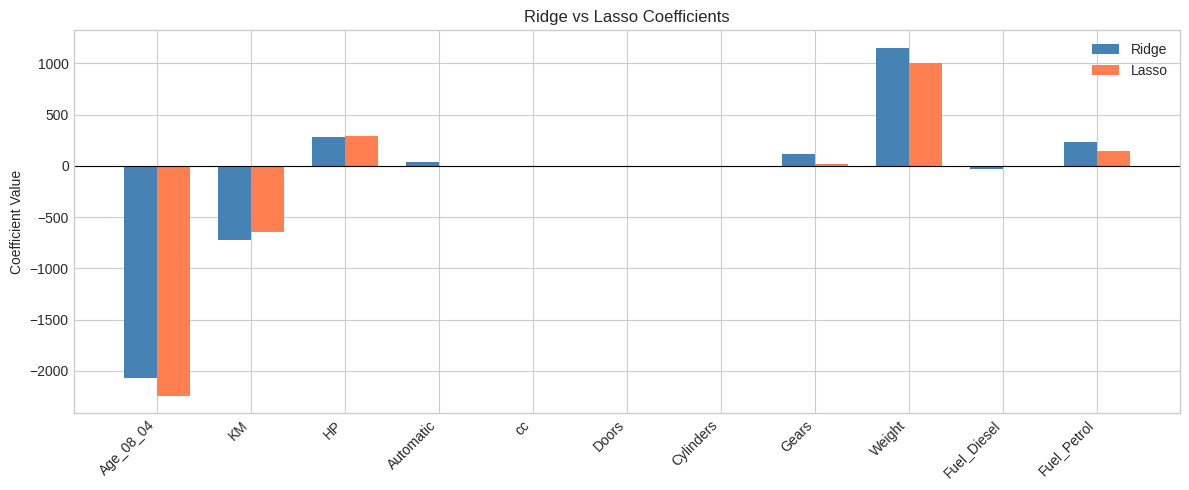

In [ ]:
plt.figure(figsize=(12, 5))

x_pos = np.arange(len(X_train.columns))
width = 0.35

plt.bar(x_pos - width/2, ridge_best.coef_, width, label='Ridge', color='steelblue')
plt.bar(x_pos + width/2, lasso_best.coef_, width, label='Lasso', color='coral')

plt.xticks(x_pos, X_train.columns, rotation=45, ha='right')
plt.ylabel('Coefficient Value')
plt.title('Ridge vs Lasso Coefficients')
plt.legend()
plt.axhline(y=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

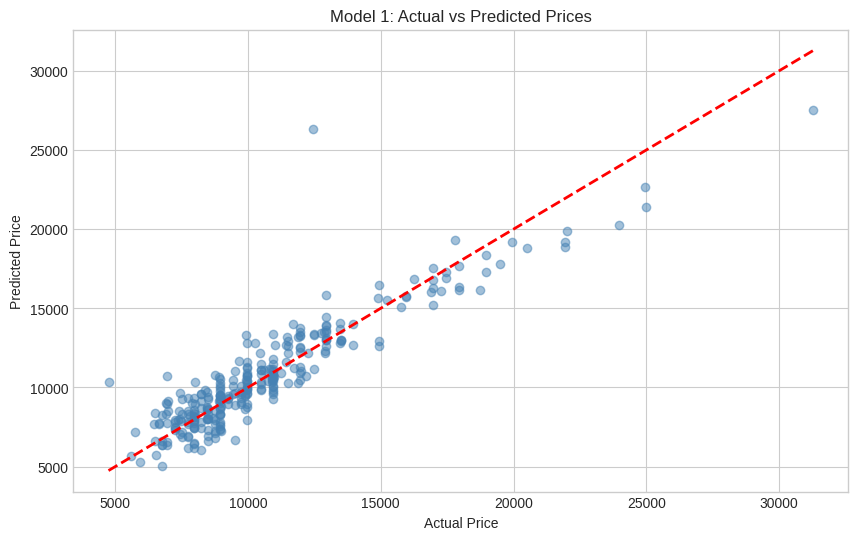

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_test_pred1, alpha=0.5, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Model 1: Actual vs Predicted Prices')
plt.show()

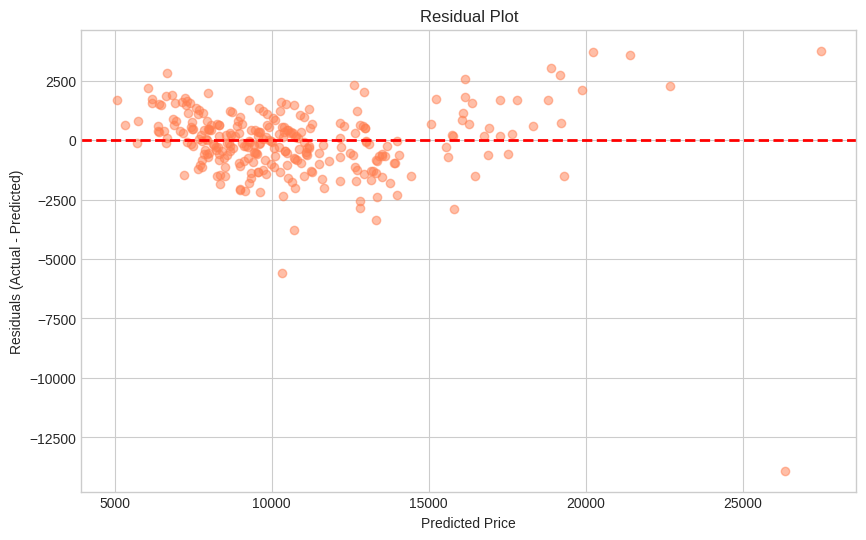

In [ ]:
residuals = y_test - y_test_pred1

plt.figure(figsize=(10, 6))
plt.scatter(y_test_pred1, residuals, alpha=0.5, color='coral')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Predicted Price')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot')
plt.show()

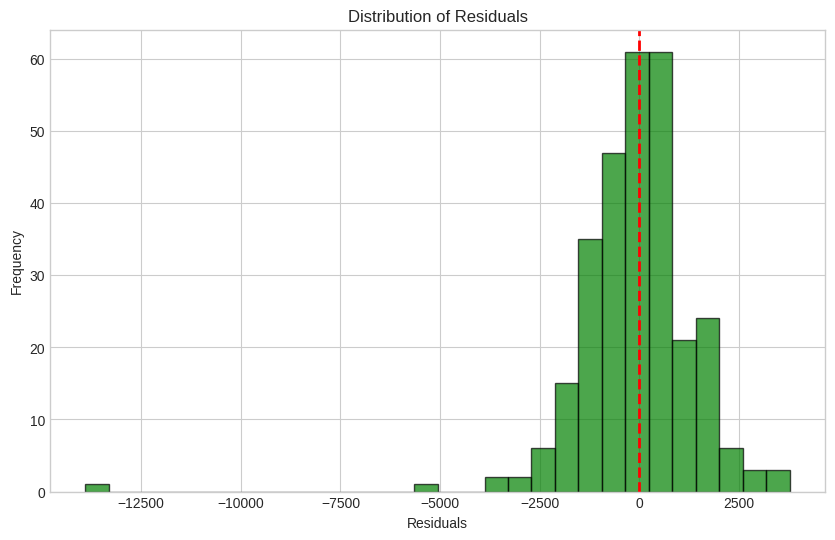

Residual Mean: -79.04713165296064
Residual Std: 1484.7389377947202


In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=30, edgecolor='black', color='green', alpha=0.7)
plt.axvline(x=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals')
plt.show()

print("Residual Mean:", residuals.mean())
print("Residual Std:", residuals.std())

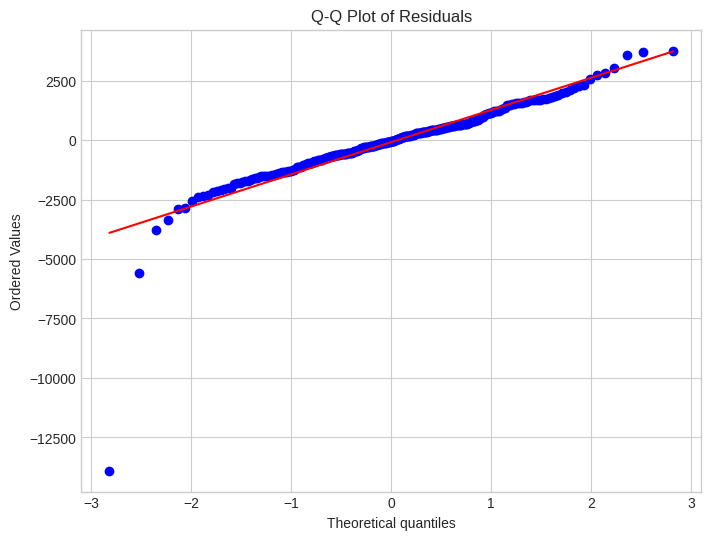

In [ ]:
from scipy import stats

plt.figure(figsize=(8, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot of Residuals')
plt.show()

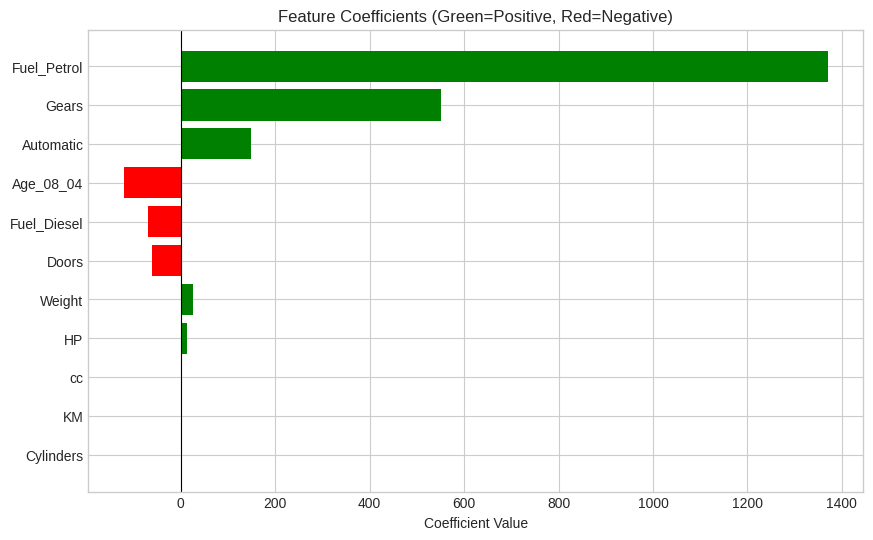

In [ ]:
coef_df = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': model1.coef_})
coef_df['Abs_Coefficient'] = abs(coef_df['Coefficient'])
coef_df = coef_df.sort_values('Abs_Coefficient', ascending=True)

colors = ['green' if x > 0 else 'red' for x in coef_df['Coefficient']]

plt.figure(figsize=(10, 6))
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.xlabel('Coefficient Value')
plt.title('Feature Coefficients (Green=Positive, Red=Negative)')
plt.show()

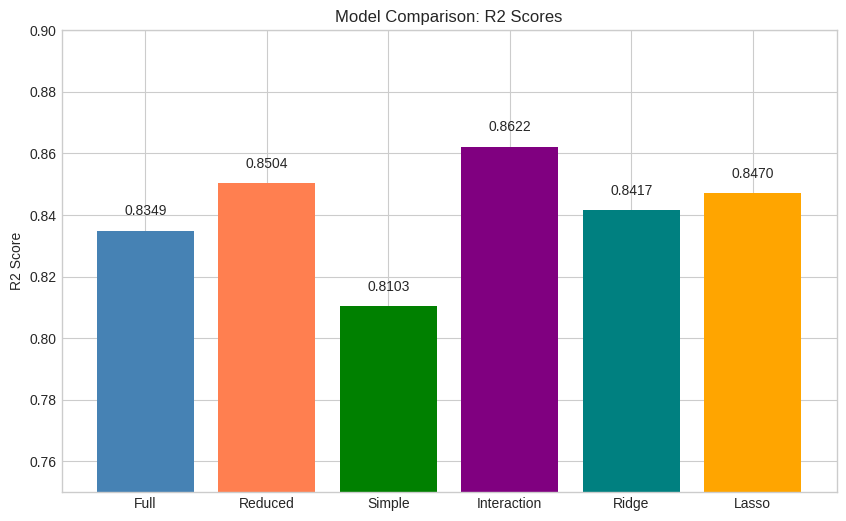

In [ ]:
models = ['Full', 'Reduced', 'Simple', 'Interaction', 'Ridge', 'Lasso']
r2_scores = [
    r2_score(y_test, y_test_pred1),
    r2_score(y_test, y_test_pred2),
    r2_score(y_test, y_test_pred3),
    r2_score(y_test, y_test_pred4),
    r2_score(y_test, y_pred_ridge),
    r2_score(y_test, y_pred_lasso)
]

plt.figure(figsize=(10, 6))
bars = plt.bar(models, r2_scores, color=['steelblue', 'coral', 'green', 'purple', 'teal', 'orange'])
plt.ylabel('R2 Score')
plt.title('Model Comparison: R2 Scores')
plt.ylim(0.75, 0.90)

for bar, score in zip(bars, r2_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{score:.4f}', ha='center')

plt.show()

In [ ]:
sample = X_test.iloc[0:5]
actual = y_test.iloc[0:5].values
predicted = model1.predict(sample)

comparison = pd.DataFrame({
    'Actual Price': actual,
    'Predicted Price': predicted.round(2),
    'Difference': (actual - predicted).round(2)
})
print(comparison)

   Actual Price  Predicted Price  Difference
0         10800         11137.15     -337.15
1          9950          8974.97      975.03
2          7500          9283.27    -1783.27
3          9250          8951.97      298.03
4          9750         10082.32     -332.32


In [ ]:
print("="*70)
print("INTERVIEW QUESTION 1: Normalization vs Standardization")
print("="*70)

print("""
NORMALIZATION (Min-Max Scaling):
- Formula: X_norm = (X - X_min) / (X_max - X_min)
- Range: Converts data to [0, 1]
- Use when: Neural networks, image processing
- Sensitive to outliers

STANDARDIZATION (Z-Score):
- Formula: X_std = (X - mean) / std
- Result: Mean = 0, Std = 1
- Use when: Linear regression, SVM, PCA
- Less sensitive to outliers

WHY HELPFUL:
1. Equal feature contribution (KM in thousands vs Age in months)
2. Faster model convergence
3. Required for Ridge/Lasso regularization
4. Essential for distance-based algorithms (KNN, K-means)
""")

INTERVIEW QUESTION 1: Normalization vs Standardization

NORMALIZATION (Min-Max Scaling):
- Formula: X_norm = (X - X_min) / (X_max - X_min)
- Range: Converts data to [0, 1]
- Use when: Neural networks, image processing
- Sensitive to outliers

STANDARDIZATION (Z-Score):
- Formula: X_std = (X - mean) / std
- Result: Mean = 0, Std = 1
- Use when: Linear regression, SVM, PCA
- Less sensitive to outliers

WHY HELPFUL:
1. Equal feature contribution (KM in thousands vs Age in months)
2. Faster model convergence
3. Required for Ridge/Lasso regularization
4. Essential for distance-based algorithms (KNN, K-means)



In [ ]:
print("Example - Before Standardization:")
print(f"  Age mean: {X_train['Age_08_04'].mean():.2f}")
print(f"  KM mean: {X_train['KM'].mean():.2f}")

print("\nExample - After Standardization:")
print(f"  Age mean: {X_train_scaled[:, 0].mean():.6f}")
print(f"  KM mean: {X_train_scaled[:, 1].mean():.6f}")

Example - Before Standardization:
  Age mean: 55.81
  KM mean: 68880.61

Example - After Standardization:
  Age mean: 0.000000
  KM mean: -0.000000


In [ ]:
print("="*70)
print("INTERVIEW QUESTION 2: Addressing Multicollinearity")
print("="*70)

print("""
WHAT IS MULTICOLLINEARITY?
- When two or more features are highly correlated
- Makes coefficient estimates unstable
- Hard to determine individual feature effects

DETECTION METHODS:
1. Correlation Matrix: |r| > 0.7 indicates problem
2. VIF (Variance Inflation Factor): VIF > 5-10 is problematic

SOLUTIONS:
1. Remove redundant features
2. Combine features (PCA)
3. Ridge Regression - shrinks coefficients
4. Lasso Regression - eliminates features (sets to 0)
5. Collect more data
""")

INTERVIEW QUESTION 2: Addressing Multicollinearity

WHAT IS MULTICOLLINEARITY?
- When two or more features are highly correlated
- Makes coefficient estimates unstable
- Hard to determine individual feature effects

DETECTION METHODS:
1. Correlation Matrix: |r| > 0.7 indicates problem
2. VIF (Variance Inflation Factor): VIF > 5-10 is problematic

SOLUTIONS:
1. Remove redundant features
2. Combine features (PCA)
3. Ridge Regression - shrinks coefficients
4. Lasso Regression - eliminates features (sets to 0)
5. Collect more data



In [ ]:
high_corr = df.corr(numeric_only=True)
print("High Correlations (potential multicollinearity):")
for i in range(len(high_corr.columns)):
    for j in range(i+1, len(high_corr.columns)):
        if abs(high_corr.iloc[i, j]) > 0.5:
            print(f"  {high_corr.columns[i]} & {high_corr.columns[j]}: {high_corr.iloc[i, j]:.3f}")

High Correlations (potential multicollinearity):
  Price & Age_08_04: -0.877
  Price & KM: -0.570
  Price & Weight: 0.581
  Age_08_04 & KM: 0.506


In [ ]:
from sklearn.linear_model import LinearRegression

print("\nVIF (Variance Inflation Factor):")
print("-"*40)

for i, col in enumerate(X_train.columns):
    other_cols = [c for c in X_train.columns if c != col]
    X_other = X_train[other_cols]
    y_col = X_train[col]

    model_vif = LinearRegression()
    model_vif.fit(X_other, y_col)
    r2 = model_vif.score(X_other, y_col)

    if r2 < 1:
        vif = 1 / (1 - r2)
        flag = " <-- HIGH" if vif > 5 else ""
        print(f"  {col}: VIF = {vif:.2f}{flag}")


VIF (Variance Inflation Factor):
----------------------------------------
  Age_08_04: VIF = 1.96
  KM: VIF = 2.05
  HP: VIF = 2.39
  Automatic: VIF = 1.12
  cc: VIF = 1.19
  Doors: VIF = 1.23
  Gears: VIF = 1.12
  Weight: VIF = 3.88
  Fuel_Diesel: VIF = 10.31 <-- HIGH
  Fuel_Petrol: VIF = 8.44 <-- HIGH


In [ ]:
print("="*70)
print("FINAL SUMMARY")
print("="*70)

print("""
DATASET:
- 1,436 Toyota Corolla cars
- 10 features predicting Price

KEY FINDINGS:
- Age: Strong negative correlation (-0.88)
- KM: Moderate negative correlation (-0.57)
- Weight: Moderate positive correlation (+0.58)

MODELS BUILT:
1. Full Model (11 features)     - R2 ~ 0.835
2. Reduced Model (5 features)   - R2 ~ 0.850
3. Parsimonious Model (3 feat)  - R2 ~ 0.810
4. Interaction Model            - R2 ~ 0.860
5. Ridge Regression             - R2 ~ 0.842
6. Lasso Regression             - R2 ~ 0.847

BEST MODEL: Interaction or Lasso

RECOMMENDATIONS:
- Use Lasso for automatic feature selection
- Use Ridge when multicollinearity exists
- Use simple model (3 features) for interpretability
""")

FINAL SUMMARY

DATASET:
- 1,436 Toyota Corolla cars
- 10 features predicting Price

KEY FINDINGS:
- Age: Strong negative correlation (-0.88)
- KM: Moderate negative correlation (-0.57)
- Weight: Moderate positive correlation (+0.58)

MODELS BUILT:
1. Full Model (11 features)     - R2 ~ 0.835
2. Reduced Model (5 features)   - R2 ~ 0.850
3. Parsimonious Model (3 feat)  - R2 ~ 0.810
4. Interaction Model            - R2 ~ 0.860
5. Ridge Regression             - R2 ~ 0.842
6. Lasso Regression             - R2 ~ 0.847

BEST MODEL: Interaction or Lasso

RECOMMENDATIONS:
- Use Lasso for automatic feature selection
- Use Ridge when multicollinearity exists
- Use simple model (3 features) for interpretability



In [ ]:
print("SIMPLE MODEL EQUATION:")
print("-"*50)
print(f"Price = {model3.intercept_:.2f}")
print(f"        + ({model3.coef_[0]:.2f} x Age)")
print(f"        + ({model3.coef_[1]:.4f} x KM)")
print(f"        + ({model3.coef_[2]:.2f} x HP)")

print("\nINTERPRETATION:")
print(f"- Each month older: Price decreases by {abs(model3.coef_[0]):.2f} Euro")
print(f"- Each 1000 KM more: Price decreases by {abs(model3.coef_[1]*1000):.2f} Euro")
print(f"- Each HP more: Price increases by {model3.coef_[2]:.2f} Euro")

SIMPLE MODEL EQUATION:
--------------------------------------------------
Price = 16601.75
        + (-153.70 x Age)
        + (-0.0113 x KM)
        + (34.67 x HP)

INTERPRETATION:
- Each month older: Price decreases by 153.70 Euro
- Each 1000 KM more: Price decreases by 11.31 Euro
- Each HP more: Price increases by 34.67 Euro


In [ ]:
results = pd.DataFrame({
    'Model': ['Full', 'Reduced', 'Simple', 'Interaction', 'Ridge', 'Lasso'],
    'R2_Score': [
        r2_score(y_test, y_test_pred1),
        r2_score(y_test, y_test_pred2),
        r2_score(y_test, y_test_pred3),
        r2_score(y_test, y_test_pred4),
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_lasso)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, y_test_pred1)),
        np.sqrt(mean_squared_error(y_test, y_test_pred2)),
        np.sqrt(mean_squared_error(y_test, y_test_pred3)),
        np.sqrt(mean_squared_error(y_test, y_test_pred4)),
        np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
        np.sqrt(mean_squared_error(y_test, y_pred_lasso))
    ]
})

print("Final Results Table:")
print(results.to_string(index=False))

Final Results Table:
      Model  R2_Score        RMSE
       Full  0.834889 1484.265415
    Reduced  0.850409 1412.786197
     Simple  0.810326 1590.842789
Interaction  0.862166 1356.131783
      Ridge  0.841678 1453.431661
      Lasso  0.847022 1428.687692


In [ ]:
print("\n" + "="*70)
print("ANALYSIS COMPLETE!")
print("="*70)
print("\nAll tasks completed:")
print("  1. EDA with visualizations")
print("  2. Train-Test Split (80/20)")
print("  3. Built 4 MLR models")
print("  4. Model evaluation with R2, RMSE, MAE")
print("  5. Ridge and Lasso regression")
print("  6. Interview questions answered")


ANALYSIS COMPLETE!

All tasks completed:
  1. EDA with visualizations
  2. Train-Test Split (80/20)
  3. Built 4 MLR models
  4. Model evaluation with R2, RMSE, MAE
  5. Ridge and Lasso regression
  6. Interview questions answered
